In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# parameters
mu = 0.5                                      # Mean Number of Photons/Pulse
alpha_values =  np.arange(1, 32, 0.5)           # Attenuation in Weather in dB/Km
delta_f = 1e3                                 # Linewidth in Hz
d_t = 1e-9                                    # 1/Bit rate
R_b = 1e9                                     # Bit rate
L = 1                                         # Transmission Distance in Km
t_B = 0.5                                     # Transmittance of BS
loss_MZI = 1 * 10**(-0.2)                     # 2 dB loss in MZI
theta = 0                                     # Phase difference of two consecutive pulses
eta = 0.2                                     # Efficiency of SPD
P_d = 2e-7                                    # Dark Count Probability
t_d = 10e-9                                   # Dead Time in SPD
t_BSE = 0.8                                   # Transmittance of Eve's BS
f_decoy = 0.2                                 # Probability used to generate the decoy state
duty_cycle_TTL = 0.75                         # Duty cycle of TTL pulses
f = 1.16                                      # Error correction efficiency
D_t = np.arange(0.000001, 0.000105, 0.000001) # Transmeter Aperture in Km
D_r_values = np.arange(0.000001, 0.000105, 0.000001) # Recevier Aperture in Km
D = 0.000025                                  # Beam Divergence
X = []
Y = []
Z = []
Color = []

for alpha in alpha_values:

    for D_r in D_r_values:

        # Phase Noise at LASER
        sigma = np.sqrt(2 * np.pi * delta_f * d_t)

        # Channel transmittance
        eta_channel = (D_r /(D_t + D * L))**2 * 10**(-alpha * L / 10)

        Photon_count_after_channel = mu * eta_channel * R_b
        
        # DATA LINE

        Photon_count_after_BS = mu * eta_channel * R_b * t_B

        Photon_count_after_D_d = Photon_count_after_BS * eta + P_d * R_b

        effective_time_difference_D_d = 1 / Photon_count_after_D_d + t_d

        effective_counts_D_d = (1 / effective_time_difference_D_d) * duty_cycle_TTL

        # MONITORING LINE

        Photon_count_after_BS = mu * 10 ** (-alpha * L / 10) * R_b * (1 - t_B)

        Photon_Count_MZI_Upper = (loss_MZI * mu * eta_channel * R_b * (1 - t_B)* ((1 + np.exp(-(sigma ** 2) / 2) * np.cos(theta)) / 2))

        Photon_Count_MZI_Lower = (loss_MZI * mu * eta_channel * R_b * (1 - t_B) * ((1 - np.exp(-(sigma ** 2) / 2) * np.cos(theta)) / 2))

        Photon_Count_before_SPD_0 = Photon_Count_MZI_Upper
        Photon_Count_before_SPD_1 = Photon_Count_MZI_Lower

        Photon_Count_after_SPD_0 = Photon_Count_before_SPD_0 * eta + P_d * R_b
        Photon_Count_after_SPD_1 = Photon_Count_before_SPD_1 * eta + P_d * R_b

        effective_time_difference_SPD_0 = 1 / Photon_Count_after_SPD_0 + t_d
        effective_time_difference_SPD_1 = 1 / Photon_Count_after_SPD_1 + t_d

        effective_counts_SPD_0 = ((1 / effective_time_difference_SPD_0) * duty_cycle_TTL)
        effective_counts_SPD_1 = ( (1 / effective_time_difference_SPD_1) * duty_cycle_TTL )

        total_counts_D_M1 = ((1 / effective_time_difference_SPD_0) * duty_cycle_TTL * (2 * f_decoy + (1 - f_decoy) ** 2 / 2))
        total_counts_D_M2 = ((1 / effective_time_difference_SPD_1) * duty_cycle_TTL * (2 * f_decoy + (1 - f_decoy) ** 2 / 2))

        # Visibility
        V = (total_counts_D_M1 - total_counts_D_M2) / (total_counts_D_M1 + total_counts_D_M2)
        # QBER
        Q_0 = (1 - V) / 2
        Q = (1 - V) * 100 / 2
        
        X.extend(D_t * 1e6)
        Y.extend(np.ones_like(D_t) * D_r* 1e6)
        Z.extend(np.ones_like(D_t) * alpha)
        Color.extend(Q)


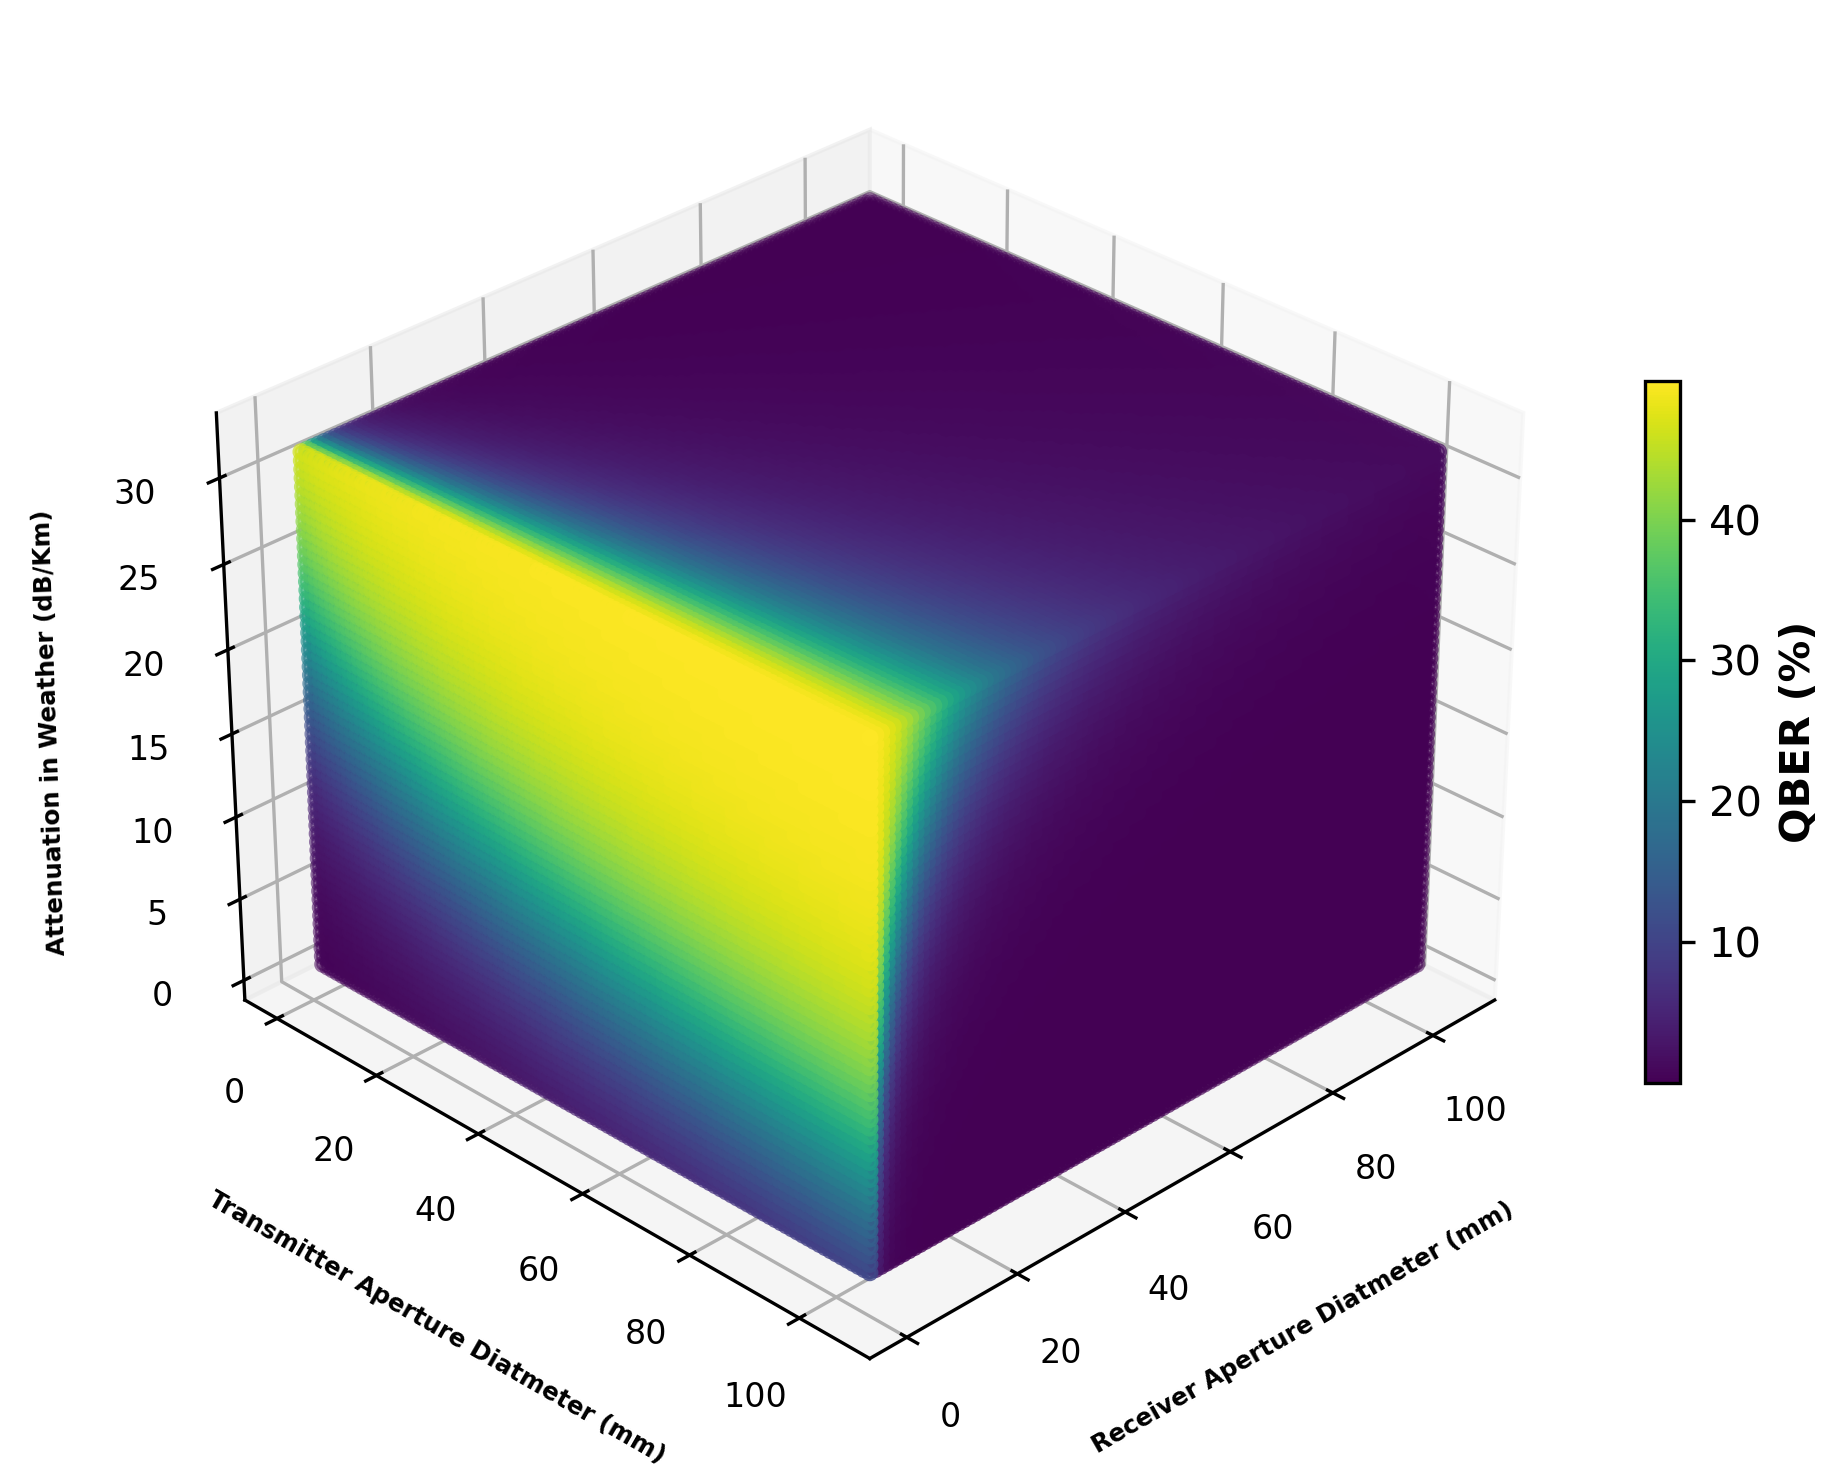

In [2]:
# Plot
fig = plt.figure(figsize=(9, 6.5), dpi=300)
ax = fig.add_axes([0.16, 0.16, 0.68, 0.72], projection='3d')
sc = ax.scatter(Y,X,Z,c=Color,cmap='viridis',s=10)
ax.set_xlabel('Receiver Aperture Diatmeter (mm)', fontsize=5.9, labelpad=8, fontweight='bold')
ax.set_ylabel('Transmitter Aperture Diatmeter (mm)', fontsize=5.9, labelpad=8, fontweight='bold')

ax.set_zticks(np.arange(0, 31, 5))
ax.invert_xaxis()
ax.view_init(elev=30, azim=45)
ax.tick_params(axis='both', labelsize=8)
ax.tick_params(axis='z', labelsize=8)
fig.text(0.14,0.52,r'Attenuation in Weather (dB/Km)',rotation=92,fontsize=5.9,va='center',fontweight='bold')
cbar = fig.colorbar(sc, ax=ax, shrink=0.50, pad=0.05)
cbar.set_label('QBER (%)', fontsize=10, fontweight='bold')
plt.savefig(r"QBER_plot_FSO_d_r_d_t.png",dpi=300, bbox_inches="tight")
plt.show()